# Requerimientos

In [3]:
#AGREGAR DE LA ESPERANZA Y EL BROWNIANO GEOMÉTRICO HACE QUE LA ESPERANZA SEA 0. 
#ASÍ NO HAY ARBITRAJE Y PUEDO CALCULAR UNA ESPERANZA QUE ME DA EL PRECIO DE AL OPCIÓN
#Relación con una martingala? eliminas la presencia de arbitraje, es lo que más te importa
#Cuando sale la fórmula, la deriva desaparece y solo no conoces la volatilidad que con xi cuadrada. Conoces todo menos la sigma. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as si

In [4]:
#Parámetro y de la opción
S0 = 100.0    # Precio inicial del activo subyacente
K = 105.0     # Precio de ejercicio (Strike)
T = 1.0       # Tiempo hasta la expiración en años (1 año)
r = 0.05      # Tasa de interés libre de riesgo (5%)
sigma = 0.20  # Volatilidad anualizada (20%)

# Parámetros de la simulación
M = 50        # Número de pasos de tiempo (ej. semanas o días)
I = 10000     # Número de simulaciones (trayectorias)

# Precio teórico

In [6]:
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = (S * si.norm.cdf(d1, 0.0, 1.0) - K * np.exp(-r * T) * si.norm.cdf(d2, 0.0, 1.0))
    return call_price

precio_teorico = black_scholes_call(S0, K, T, r, sigma)
print(f"Precio teórico del Call (Black-Scholes): {precio_teorico:.4f}")

Precio teórico del Call (Black-Scholes): 8.0214


# Simulación Monte Carlo

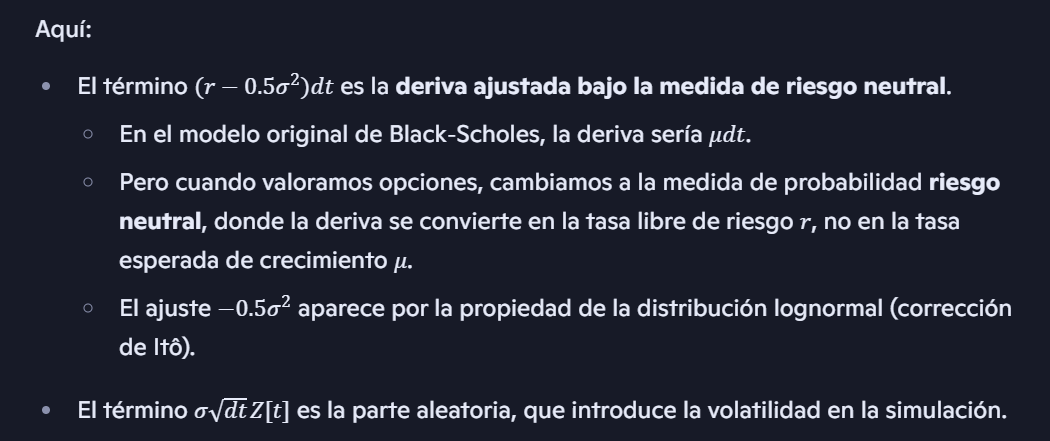

In [7]:
# Calculamos el tamaño del paso de tiempo
dt = T / M

# Generamos una matriz de variables normales aleatorias
Z = np.random.standard_normal((M + 1, I))

# Inicializamos la matriz de precios con ceros y establecemos el precio inicial
S = np.zeros((M + 1, I))
S[0] = S0

# Simulamos los caminos
for t in range(1, M + 1): #deriva calculada y ajustada a la medida de riesgo neutral
    S[t] = S[t - 1] * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z[t])

# Calculamos el Payoff al vencimiento (solo nos importa el último precio S[-1])
# El payoff de un call es max(S_T - K, 0)
payoffs = np.maximum(S[-1] - K, 0)

# El precio de la opción es el valor presente del promedio de los payoffs
precio_simulado = np.exp(-r * T) * np.sum(payoffs) / I

print(f"Precio simulado del Call (Monte Carlo): {precio_simulado:.4f}")

Precio simulado del Call (Monte Carlo): 8.0050


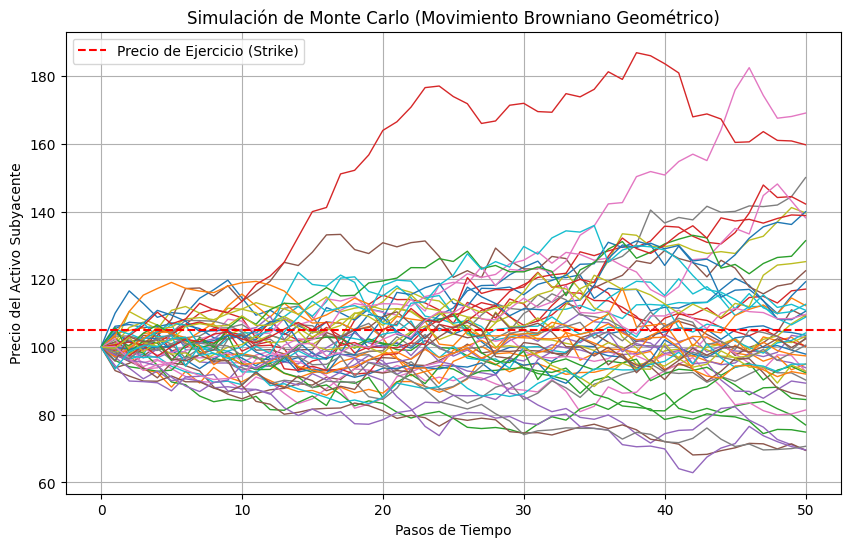

In [8]:
plt.figure(figsize=(10, 6))
# Graficamos solo las primeras 50 trayectorias para no saturar la imagen
plt.plot(S[:, :50], lw=1.0)
plt.axhline(K, color='r', linestyle='--', label='Precio de Ejercicio (Strike)')
plt.xlabel('Pasos de Tiempo')
plt.ylabel('Precio del Activo Subyacente')
plt.title('Simulación de Monte Carlo (Movimiento Browniano Geométrico)')
plt.legend()
plt.grid(True)
plt.show()

# Aplicado al mercado mexicano


In [14]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 8.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.3.1
    Uninstalling pip-24.3.1:
      Successfully uninstalled pip-24.3.1
Note: you may need to restart the kernel to use updated packages.


In [4]:
!pip install --upgrade yfinance
import numpy as np
import scipy.stats as si
import pandas as pd
import yfinance as yf

In [10]:
# 1. Definir el Ticker Mexicano y descargar historial (ej. último año)
ticker = "WALMEX.MX"
datos = yf.download(ticker, period="1y")

# 2. Calcular los retornos logarítmicos diarios
datos['Retornos'] = np.log(datos['Close'] / datos['Close'].shift(1))

# 3. Calcular la Volatilidad Histórica Anualizada (asumiendo 252 días bursátiles)
volatilidad = datos['Retornos'].std() * np.sqrt(252)

# Obtener el precio actual (S0)
S0 = float(datos['Close'].iloc[-1].iloc[0])

print(f"--- DATOS DEL MERCADO MEXICANO ({ticker}) ---")
print(f"Precio actual del subyacente (S0): ${S0:.2f} MXN")
print(f"Volatilidad histórica anualizada (sigma): {volatilidad * 100:.2f}%")


[*********************100%***********************]  1 of 1 completed

--- DATOS DEL MERCADO MEXICANO (WALMEX.MX) ---
Precio actual del subyacente (S0): $54.87 MXN
Volatilidad histórica anualizada (sigma): 25.16%


In [7]:
# --- PARÁMETROS MANUALES (Sustituye por lo que veas en el mercado) ---
K = 54.00        # Precio de ejercicio (Strike) que viste en MexDer
T = 0.5          # Tiempo de expiración (ej. 6 meses = 0.5 años)
r = 0.108        # Tasa libre de riesgo en México (CETES a 6 meses, ej. 10.8%)

# Este es el precio real (Ask/Bid) que alguien está cobrando en el MexDer
precio_mercado_real = 2.45 

# --- MODELO BLACK-SCHOLES ---
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return (S * si.norm.cdf(d1, 0.0, 1.0) - K * np.exp(-r * T) * si.norm.cdf(d2, 0.0, 1.0))

precio_teorico = black_scholes_call(S0, K, T, r, volatilidad)

# --- COMPARACIÓN ---
print(f"--- RESULTADOS DE LA VALUACIÓN ---")
print(f"Precio Teórico (Black-Scholes): ${precio_teorico:.4f} MXN")
print(f"Precio en el MexDer (Mercado):  ${precio_mercado_real:.4f} MXN")

diferencia = precio_mercado_real - precio_teorico
if diferencia > 0:
    print(f"Conclusión: La opción en el mercado está SOBREVALORADA por ${diferencia:.4f} MXN respecto al modelo.")
else:
    print(f"Conclusión: La opción en el mercado está SUBVALORADA por ${abs(diferencia):.4f} MXN respecto al modelo.")

--- RESULTADOS DE LA VALUACIÓN ---
Precio Teórico (Black-Scholes): $3.8512 MXN
Precio en el MexDer (Mercado):  $2.4500 MXN
Conclusión: La opción en el mercado está SUBVALORADA por $1.4012 MXN respecto al modelo.


Descargando datos de GFNORTEO.MX...


[*********************100%***********************]  1 of 1 completed


----------------------------------------
Precio actual (S0): $194.76 MXN
Strike (K): $204.50 MXN
Volatilidad histórica: 26.29%
----------------------------------------
Precio Call (Black-Scholes): $14.9911 MXN
Precio Call (Monte Carlo):   $14.9679 MXN


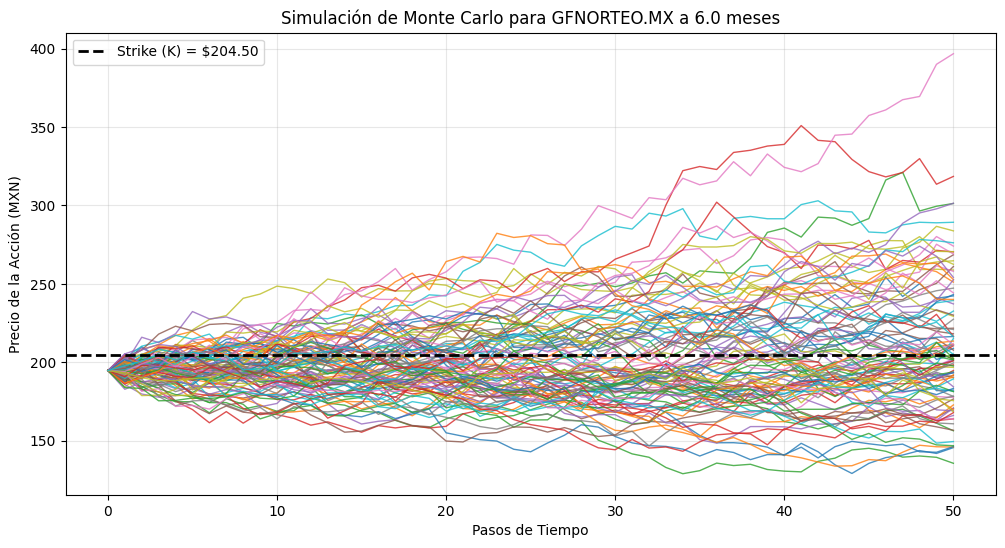

In [12]:
#Grypo Financiero Banorte 

import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as si
# --- 1. EXTRACCIÓN DE DATOS REALES (BANORTE) ---
ticker = "GFNORTEO.MX"
print(f"Descargando datos de {ticker}...")
# Desactivamos auto_adjust para evitar problemas con Yahoo Finance
datos = yf.download(ticker, period="1y", auto_adjust=False, actions=False)

# Calculamos retornos logarítmicos y volatilidad anualizada
datos['Retornos'] = np.log(datos['Adj Close'] / datos['Adj Close'].shift(1))
volatilidad = datos['Retornos'].std() * np.sqrt(252)

# Extraemos el precio actual de forma segura usando .item() para evitar la advertencia (warning)
S0 = float(datos['Adj Close'].iloc[-1].item())

# --- 2. DEFINICIÓN DE PARÁMETROS DEL MERCADO MEXICANO ---
# Vamos a suponer que queremos evaluar un Call que vence en 6 meses
T = 0.5  
r = 0.11 # Tasa libre de riesgo (CETES a 6 meses, ej. 11%)

# Definimos el Strike (K) ligeramente por encima del precio actual ("Out of the money")
K = S0 * 1.05 

print("-" * 40)
print(f"Precio actual (S0): ${S0:.2f} MXN")
print(f"Strike (K): ${K:.2f} MXN")
print(f"Volatilidad histórica: {volatilidad * 100:.2f}%")
print("-" * 40)

# --- 3. SIMULACIÓN DE MONTE CARLO ---
M = 50        # Número de pasos de tiempo en la simulación
I = 10000     # Número de trayectorias (escenarios posibles)
dt = T / M    # Tamaño de cada paso

# Matriz de números aleatorios (Z) y matriz para guardar los precios simulados (S)
Z = np.random.standard_normal((M + 1, I))
S = np.zeros((M + 1, I))
S[0] = S0

# Generamos los caminos aleatorios usando el Movimiento Browniano Geométrico
for t in range(1, M + 1):
    S[t] = S[t - 1] * np.exp((r - 0.5 * volatilidad ** 2) * dt + volatilidad * np.sqrt(dt) * Z[t])

# Calculamos el Payoff al vencimiento y lo traemos a valor presente
payoffs = np.maximum(S[-1] - K, 0)
precio_simulado_mc = np.exp(-r * T) * np.sum(payoffs) / I

# Calculamos también el valor teórico exacto con Black-Scholes para comparar
d1 = (np.log(S0 / K) + (r + 0.5 * volatilidad ** 2) * T) / (volatilidad * np.sqrt(T))
d2 = d1 - volatilidad * np.sqrt(T)
precio_teorico_bs = (S0 * si.norm.cdf(d1, 0.0, 1.0) - K * np.exp(-r * T) * si.norm.cdf(d2, 0.0, 1.0))

print(f"Precio Call (Black-Scholes): ${precio_teorico_bs:.4f} MXN")
print(f"Precio Call (Monte Carlo):   ${precio_simulado_mc:.4f} MXN")

# --- 4. VISUALIZACIÓN DE LA SIMULACIÓN ---
plt.figure(figsize=(12, 6))
# Graficamos solo 100 trayectorias para que la gráfica sea legible
plt.plot(S[:, :100], lw=1.0, alpha=0.8)

# Línea horizontal para el Strike (K)
plt.axhline(K, color='black', linestyle='--', linewidth=2, label=f'Strike (K) = ${K:.2f}')

plt.xlabel('Pasos de Tiempo')
plt.ylabel('Precio de la Acción (MXN)')
plt.title(f'Simulación de Monte Carlo para {ticker} a {T*12} meses')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


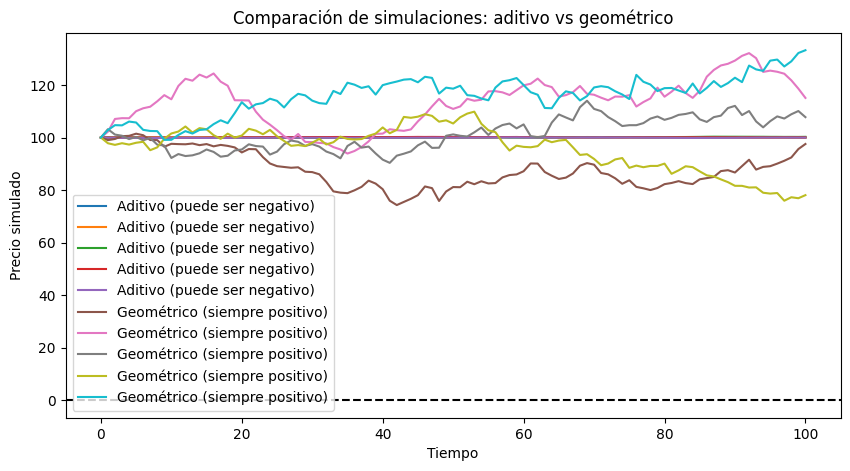

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
S0 = 100      # precio inicial
mu = 0.05     # deriva
sigma = 0.2   # volatilidad
T = 1.0       # horizonte (1 año)
M = 100       # pasos
dt = T / M
I = 5         # número de trayectorias

# Simulación aditiva
S_add = np.zeros((M+1, I))
S_add[0] = S0
for t in range(1, M+1):
    Z = np.random.standard_normal(I)
    S_add[t] = S_add[t-1] + mu*dt + sigma*np.sqrt(dt)*Z

# Simulación geométrica
S_geo = np.zeros((M+1, I))
S_geo[0] = S0
for t in range(1, M+1):
    Z = np.random.standard_normal(I)
    S_geo[t] = S_geo[t-1] * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)

# Graficamos
plt.figure(figsize=(10,5))
plt.plot(S_add, lw=1.5, label="Aditivo (puede ser negativo)")
plt.plot(S_geo, lw=1.5, label="Geométrico (siempre positivo)")
plt.axhline(0, color="black", linestyle="--")
plt.legend()
plt.title("Comparación de simulaciones: aditivo vs geométrico")
plt.xlabel("Tiempo")
plt.ylabel("Precio simulado")
plt.show()
